In [193]:
import pandas as pd
import matplotlib.pyplot as plt?
import re
import numpy as np

Type:        module
String form: <module 'matplotlib.pyplot' from 'c:\\Users\\Shivank\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\matplotlib\\pyplot.py'>
File:        c:\users\shivank\appdata\local\programs\python\python314\lib\site-packages\matplotlib\pyplot.py
Docstring:  
`matplotlib.pyplot` is a state-based interface to matplotlib. It provides
an implicit,  MATLAB-like, way of plotting.  It also opens figures on your
screen, and acts as the figure GUI manager.

pyplot is mainly intended for interactive plots and simple cases of
programmatic plot generation::

    import numpy as np
    import matplotlib.pyplot as plt

    x = np.arange(0, 5, 0.1)
    y = np.sin(x)
    plt.plot(x, y)
    plt.show()

The explicit object-oriented API is recommended for complex plots, though
pyplot is still usually used to create the figure and often the Axes in the
figure. See `.pyplot.figure`, `.pyplot.subplots`, and
`.pyplot.subplot_mosaic` to create figures, and
:doc:`Axes API

In [194]:
pd.set_option('display.max_columns', None)

In [195]:
df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

| Variable  | Definition                              | Key                                   |
|-----------|------------------------------------------|---------------------------------------|
| survival  | Survival                                 | 0 = No, 1 = Yes                      |
| pclass    | Ticket class                             | 1 = 1st, 2 = 2nd, 3 = 3rd           |
| sex       | Sex                                      | -                                     |
| age       | Age in years                             | -                                     |
| sibsp     | # of siblings / spouses aboard Titanic   | -                                     |
| parch     | # of parents / children aboard Titanic   | -                                     |
| ticket    | Ticket number                            | -                                     |
| fare      | Passenger fare                           | -                                     |
| cabin     | Cabin number                             | -                                     |
| embarked  | Port of Embarkation                      | C = Cherbourg, Q = Queenstown, S = Southampton |

# Starting with EDA

Understanding the data, rather than making graphs.

- Shape
- Info
- Describe
- Then a glimpse of data in terms of head and tail

In [196]:
df.shape

(891, 12)

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [198]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Categorize data in numerical or strings

Basically it can scale or can only have distinct values

In [199]:
# Numerical columns (int + float)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(list(numerical_cols))


# Categorical / string columns
categorical_cols = df.select_dtypes(include=['str']).columns

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [200]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Age Distribution')

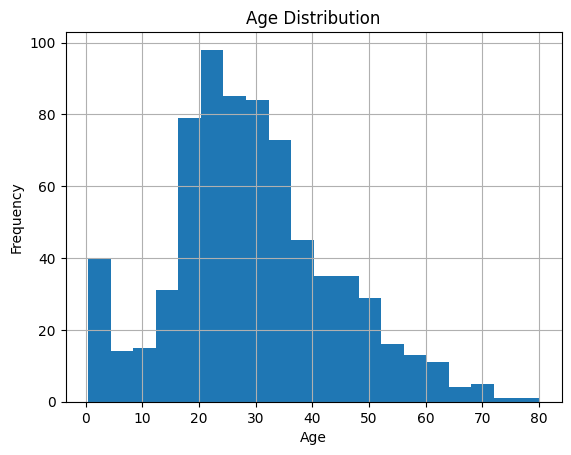

In [201]:
# Graph over Ages to see distributon

df['Age'].hist(bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

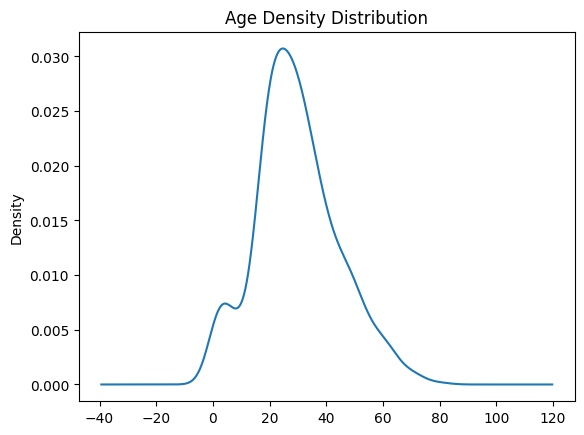

In [202]:
df['Age'].plot(kind='kde')
plt.title("Age Density Distribution")
plt.show()

In [203]:
def _handling_missing_data(df):

    df = df.copy()

    # Cabin feature
    df["HasCabin"] = df["Cabin"].notnull().astype(int)
    df.drop(columns=["Cabin"], inplace=True)

    # Age fill
    # df["Age"] = df["Age"].fillna(df["Age"].median())
    # Now filling age with median by title

    # Embarked fill
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    return df

In [204]:
import re
import numpy as np

# --- helper: clean ticket ---
def clean_ticket(ticket):
    parts = str(ticket).split()
    prefix = parts[0]
    prefix = re.sub(r'[^a-zA-Z]', '', prefix)
    return prefix.upper() if prefix != "" else "NUM"

def ticket_preprocessing(df):
    df = df.copy()

    # clean ticket
    df["Ticket_clean"] = df["Ticket"].apply(clean_ticket)

    # check if target exists
    has_target = "Survived" in df.columns

    if has_target:
        # survival rate per ticket
        ticket_rate_map = df.groupby("Ticket_clean")["Survived"].mean()

        zero_survival = ticket_rate_map[ticket_rate_map == 0].index
        full_survival = ticket_rate_map[ticket_rate_map == 1].index

        def group_ticket(x):
            if x in zero_survival:
                return "ALL_DIED"
            elif x in full_survival:
                return "ALL_SURVIVED"
            else:
                return "MIXED"

        df["Ticket_Group"] = df["Ticket_clean"].apply(group_ticket)

        global_mean = df["Survived"].mean()
        df["Ticket_Survival_Rate"] = df["Ticket_clean"].map(ticket_rate_map)

    else:
        # if no target (test set style)
        df["Ticket_Group"] = "MIXED"
        df["Ticket_Survival_Rate"] = np.nan

    return df

def add_family_size(df):
    df = df.copy()
    
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    
    return df

def add_family_size_group(df):
    df = df.copy()
    
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    def group(size):
        if size == 1:
            return 1
        elif size <= 3:
            return 2
        elif size <= 5:
            return 3
        else:
            return 4
    
    df["FamilyGroup"] = df["FamilySize"].apply(group)
    
    return df

def title_processing(df):
    df = df.copy()

    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
    df["Title"] = df["Title"].replace([
    "Capt", "Col", "Major", "Dr", "Rev", "Don", "Sir", "Jonkheer", "Lady", "Countess", "Dona"
    ], "Rare")

    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    df["Title"] = df["Title"].replace({
        "the Countess": "Rare"
    })

    return df

def fill_age_by_title(df):
    # compute median age per title
    title_age_map = df.groupby("Title")["Age"].median()

    # fill missing ages using title median
    df["Age"] = df.apply(
        lambda row: title_age_map[row["Title"]] if pd.isnull(row["Age"]) else row["Age"],
        axis=1
    )

    return df

def transform_fare(df):
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    df["Fare_log"] = np.log1p(df["Fare"])
    return df

In [205]:
def data_preprocessing(df):
    df = ticket_preprocessing(df)
    df = add_family_size(df)
    df = add_family_size_group(df)
    df["Sex_OHE"] = df["Sex"].map({"male": 1, "female": 0})
    df["Embarked_OHE"] = df["Embarked"].map({"S": 1, "C": 2, "Q": 3})
    df["Ticket_Group_OHE"] = df["Ticket_Group"].map({"ALL_DIED": 0, "MIXED": 1, "ALL_SURVIVED": 2})
    df = title_processing(df)
    df = fill_age_by_title(df)
    df = transform_fare(df)

    return df

In [206]:
df = _handling_missing_data(df)
df = data_preprocessing(df)
test_df = _handling_missing_data(test_df)
test_df = data_preprocessing(test_df)

In [207]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'HasCabin', 'Ticket_clean',
       'Ticket_Group', 'Ticket_Survival_Rate', 'FamilySize', 'FamilyGroup',
       'Sex_OHE', 'Embarked_OHE', 'Ticket_Group_OHE', 'Title', 'Fare_log'],
      dtype='str')

In [208]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = [
    "Survived",
    "Pclass",
    "Sex_OHE",
    "SibSp",
    "Parch",
    "HasCabin",
    "FamilySize",
    "Ticket_Group_OHE",
    "Fare",
]

df_plot = df[selected_cols].copy()
df_plot = pd.get_dummies(df_plot, drop_first=True)

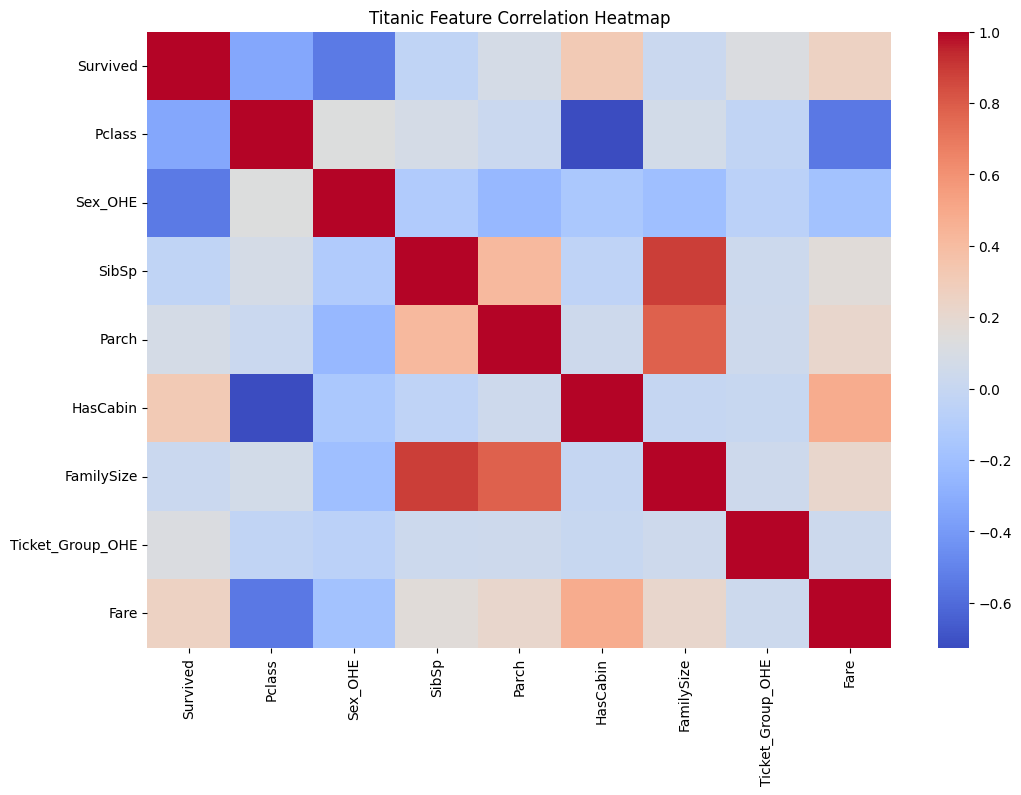

In [209]:
plt.figure(figsize=(12, 8))

corr = df_plot.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Titanic Feature Correlation Heatmap")
plt.show()

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [210]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'HasCabin', 'Ticket_clean',
       'Ticket_Group', 'Ticket_Survival_Rate', 'FamilySize', 'FamilyGroup',
       'Sex_OHE', 'Embarked_OHE', 'Ticket_Group_OHE', 'Title', 'Fare_log'],
      dtype='str')

In [211]:
# from sklearn.ensemble import RandomForestClassifier

# y = df["Survived"]

# features = [
#     "Title",
#     "Pclass",
#     "Sex_OHE",
#     "HasCabin",
#     "FamilySize",
#     "Ticket_Group_OHE",
#     "Fare_log",
# ]

# X = pd.get_dummies(df[features])
# X_test = pd.get_dummies(test_df[features])

# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
# model.fit(X, y)
# predictions = model.predict(X_test)

# output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions})
# output.to_csv('submission.csv', index=False)
# print("Your submission was successfully saved!")


In [212]:
df.isnull().sum()

PassengerId             0
Survived                0
Pclass                  0
Name                    0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Ticket                  0
Fare                    0
Embarked                0
HasCabin                0
Ticket_clean            0
Ticket_Group            0
Ticket_Survival_Rate    0
FamilySize              0
FamilyGroup             0
Sex_OHE                 0
Embarked_OHE            0
Ticket_Group_OHE        0
Title                   0
Fare_log                0
dtype: int64

In [215]:
from sklearn.ensemble import GradientBoostingClassifier

y = df["Survived"]

# # Train
# title_dummies = pd.get_dummies(df["Title"], prefix="Title")
# df = pd.concat([df, title_dummies], axis=1)
# df.drop(columns=["Title"], inplace=True)

# Test
# test_title_dummies = pd.get_dummies(test_df["Title"], prefix="Title")
# test_df = pd.concat([test_df, test_title_dummies], axis=1)
# test_df.drop(columns=["Title"], inplace=True)

test_df = test_df.reindex(columns=df.columns, fill_value=0)

features = [
    "Pclass",
    "Sex_OHE",
    "HasCabin",
    "SibSp",
    "Parch",
    "Ticket_Group_OHE",
    "Fare_log",
    "Age",
    # "Title_Master",
    # "Title_Miss",
    # "Title_Mr",
    # "Title_Mrs",
    # "Title_Rare"
]

X = pd.get_dummies(df[features])
X_test = pd.get_dummies(test_df[features])

X_test = X_test.reindex(columns=X.columns, fill_value=0)

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=1
)

model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
